# Generator analysis from grid data

Compare the empirical population map, its second-order generator approximation, and the full-channel spectral separation.


In [ ]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PLOT_DIR = Path('docu/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)


## Load grid


In [ ]:
grid_nr = 3
N = 4
path = Path(f'data/grid/superoperator_N{N}_grid_{grid_nr}.npz')

data = np.load(path)
grid_h_over_J = data['h_over_J'] if 'h_over_J' in data.files else data['h']

print(f'Loaded: {path}')
print(f"Grid points: {len(data['h'])}")
print('alpha values:', np.unique(data['alpha']).tolist())
print('sigma values:', np.unique(data['sigma']).tolist())


## Population-map spectra and gaps


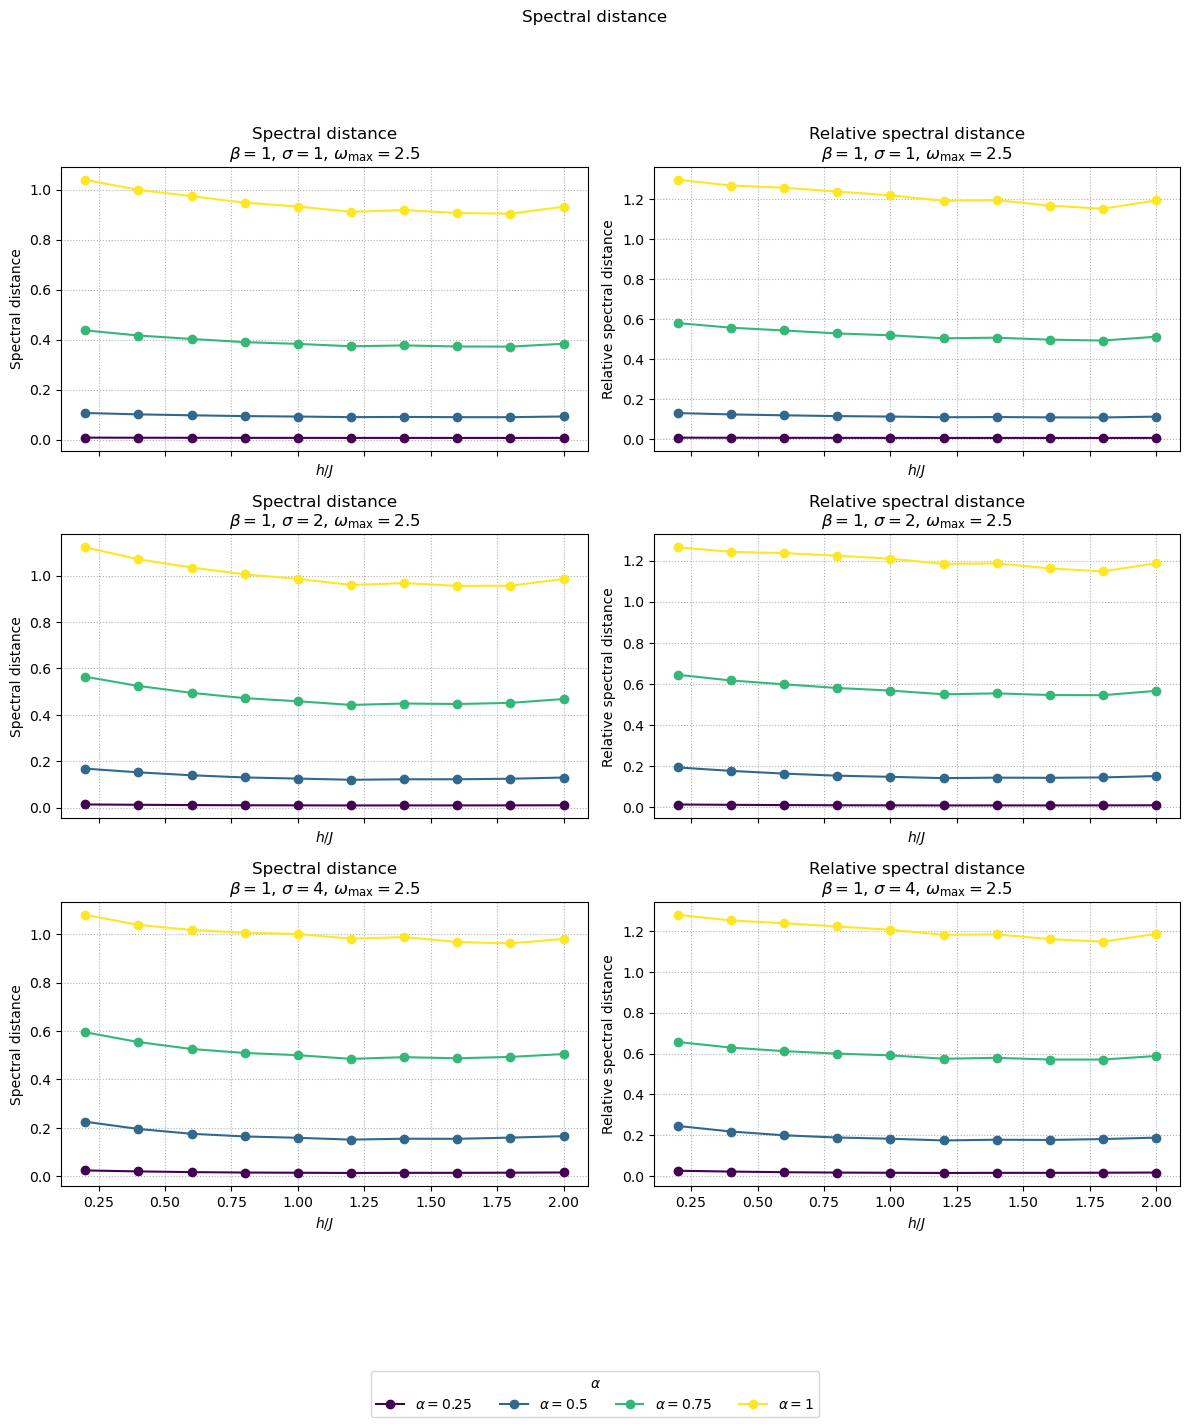

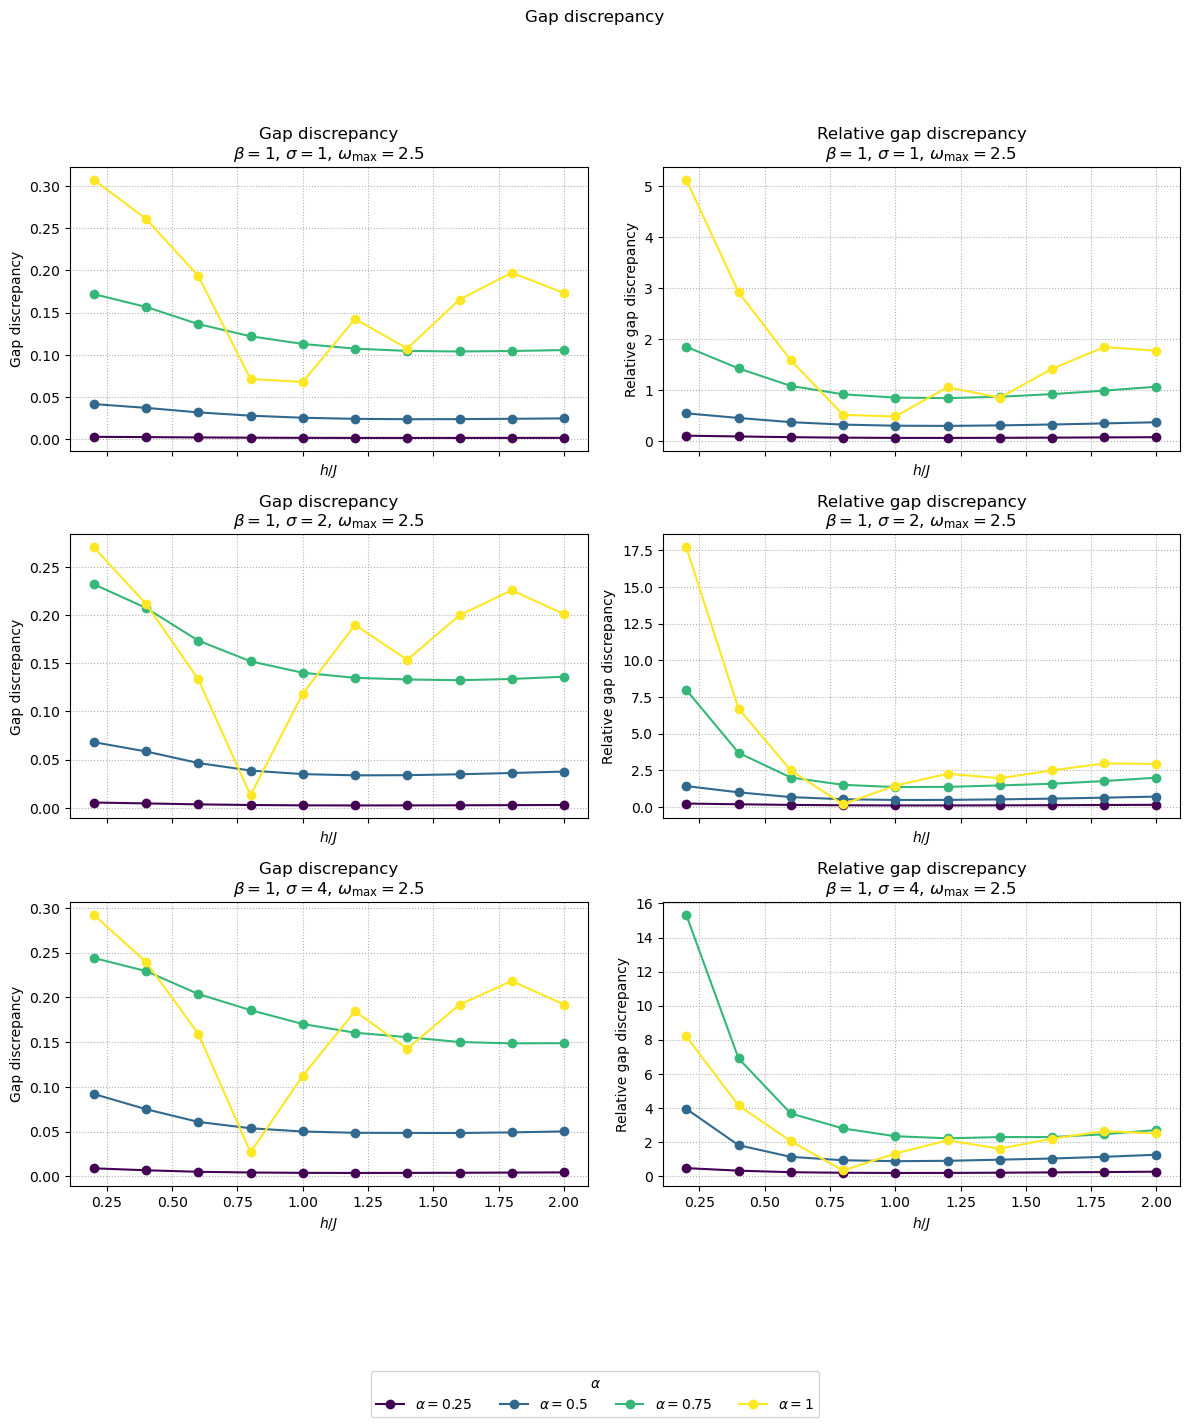

,h_over_J,alpha,sigma,omega_max,beta,spectral_distance,relative_spectral_distance,population_gap,second_order_gap,gap_discrepancy,relative_gap_discrepancy,signed_gap_discrepancy
0,0.2,0.25,1.0,2.5,1.0,0.007558,0.008082,0.026436,0.029397,0.002961,0.111995,-0.002961
1,0.2,0.75,1.0,2.5,1.0,0.436829,0.580280,0.092652,0.264575,0.171923,1.855581,-0.171923
2,0.2,0.75,2.0,2.5,1.0,0.564198,0.644796,0.029063,0.261018,0.231954,7.980977,-0.231954
3,0.2,0.50,1.0,2.5,1.0,0.106195,0.130934,0.075872,0.117589,0.041717,0.549827,-0.041717
4,0.2,0.50,2.0,2.5,1.0,0.168029,0.194516,0.047922,0.116008,0.068085,1.420741,-0.068085
...,...,...,...,...,...,...,...,...,...,...,...,...
115,2.0,0.75,2.0,2.5,1.0,0.468258,0.566771,0.068122,0.204121,0.136000,1.996426,-0.136000
116,2.0,0.75,4.0,2.5,1.0,0.504999,0.587771,0.055150,0.204071,0.148921,2.700284,-0.148921
117,2.0,1.00,1.0,2.5,1.0,0.931857,1.192801,0.097450,0.270712,0.173262,1.777962,-0.173262
118,2.0,1.00,2.0,2.5,1.0,0.986275,1.186805,0.068454,0.269344,0.200890,2.934677,-0.200890


In [67]:
# Compare the empirical population map P with the second-order prediction
# Q_alpha = I + alpha^2 K.  This requires a grid saved with
# --save-classical-populations.
from scipy.optimize import linear_sum_assignment

required_population_keys = {'classical_populations', 'transition_generator'}
missing_population_keys = required_population_keys.difference(data.files)
if missing_population_keys:
    raise ValueError(
        'The selected archive has no population/generator data. Re-run the grid '
        'with --save-classical-populations and set grid_nr to that archive. '
        f'Missing keys: {sorted(missing_population_keys)}'
    )

population_maps = np.asarray(data['classical_populations'])
generators = np.asarray(data['transition_generator'])
if population_maps.size == 0 or generators.size == 0:
    raise ValueError('The selected archive did not save population/generator matrices.')

def matched_spectral_distance(left, right):
    """RMS distance after the minimum-cost one-to-one eigenvalue matching."""
    left_eigvals = np.linalg.eigvals(left)
    right_eigvals = np.linalg.eigvals(right)
    cost = np.abs(left_eigvals[:, None] - right_eigvals[None, :]) ** 2
    rows, cols = linear_sum_assignment(cost)
    return np.sqrt(cost[rows, cols].mean())

def discrete_gap(matrix):
    """1 - |lambda_2|, excluding the eigenvalue closest to the stationary value 1."""
    eigvals = np.linalg.eigvals(matrix)
    stationary_index = np.argmin(np.abs(eigvals - 1))
    nonstationary = np.delete(eigvals, stationary_index)
    return 1 - np.max(np.abs(nonstationary))

def spectral_rms_magnitude(matrix):
    """RMS magnitude of a map's eigenvalues, used for relative spectral error."""
    return np.sqrt(np.mean(np.abs(np.linalg.eigvals(matrix)) ** 2))

spectral_rows = []
for row_index, (population_map, generator) in enumerate(zip(population_maps, generators)):
    alpha = float(data['alpha'][row_index])
    second_order_map = np.eye(population_map.shape[0]) + alpha**2 * generator
    spectral_distance = matched_spectral_distance(population_map, second_order_map)
    population_spectrum_scale = spectral_rms_magnitude(population_map)
    population_gap = discrete_gap(population_map)
    second_order_gap = discrete_gap(second_order_map)
    gap_discrepancy = abs(population_gap - second_order_gap)
    spectral_rows.append({
        'h_over_J': grid_h_over_J[row_index],
        'alpha': alpha,
        'sigma': data['sigma'][row_index],
        'omega_max': data['omega_max'][row_index],
        'beta': data['beta'][row_index],
        'spectral_distance': spectral_distance,
        'relative_spectral_distance': (
            spectral_distance / population_spectrum_scale
            if not np.isclose(population_spectrum_scale, 0) else np.nan
        ),
        'population_gap': population_gap,
        'second_order_gap': second_order_gap,
        'gap_discrepancy': gap_discrepancy,
        'relative_gap_discrepancy': (
            gap_discrepancy / abs(population_gap)
            if not np.isclose(population_gap, 0) else np.nan
        ),
        'signed_gap_discrepancy': population_gap - second_order_gap,
    })

population_spectral_data = pd.DataFrame(spectral_rows)
alpha_levels = np.sort(population_spectral_data['alpha'].unique())
alpha_colors = {alpha: plt.cm.viridis(index / max(len(alpha_levels) - 1, 1)) for index, alpha in enumerate(alpha_levels)}
panel_columns = ['beta', 'sigma', 'omega_max']
panel_groups = list(population_spectral_data.groupby(panel_columns, sort=True))
plot_specs = [
    (
        'Spectral distance',
        [('spectral_distance', 'Spectral distance'), ('relative_spectral_distance', 'Relative spectral distance')],
        f'grid_spectral_distance_grid_{grid_nr}.png',
    ),
    (
        'Gap discrepancy',
        [('gap_discrepancy', 'Gap discrepancy'), ('relative_gap_discrepancy', 'Relative gap discrepancy')],
        f'grid_gap_discrepancy_grid_{grid_nr}.png',
    ),
]

for figure_title, metrics, filename in plot_specs:
    fig, axes = plt.subplots(
        len(panel_groups), len(metrics), figsize=(12, 4.8 * len(panel_groups)), squeeze=False, sharex=True
    )
    for row_index, ((beta, sigma, omega_max), panel_data) in enumerate(panel_groups):
        panel_title = rf'$\beta = {beta:g}$, $\sigma = {sigma:g}$, $\omega_{{\max}} = {omega_max:g}$'
        for column_index, (column, ylabel) in enumerate(metrics):
            ax = axes[row_index, column_index]
            for alpha, line_data in panel_data.groupby('alpha', sort=True):
                line_data = line_data.sort_values('h_over_J')
                ax.plot(
                    line_data['h_over_J'], line_data[column], marker='o',
                    color=alpha_colors[alpha], label=rf'$\alpha = {alpha:g}$'
                )
            ax.set_xlabel(r'$h/J$')
            ax.set_ylabel(ylabel)
            ax.set_title(ylabel + '\n' + panel_title)
            ax.grid(True, linestyle=':')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.suptitle(figure_title)
    fig.legend(handles, labels, title=r'$\alpha$', loc='lower center', ncol=len(alpha_levels), frameon=True)
    fig.tight_layout(rect=[0, 0.12, 1, 0.93])
    fig.savefig(PLOT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

population_spectral_data


## Population-map residual


In [ ]:
# Population-map residual: compare the empirical map P with the second-order
# prediction I + alpha^2 K. This requires --save-classical-populations.
from scipy.optimize import curve_fit

required_population_keys = {'classical_populations', 'transition_generator'}
missing_population_keys = required_population_keys.difference(data.files)
if missing_population_keys:
    raise ValueError(
        'The selected archive has no population/generator data. Re-run the grid '
        'with --save-classical-populations. '
        f'Missing keys: {sorted(missing_population_keys)}'
    )

population_residual_rows = []
for row_index, (population_map, generator) in enumerate(
    zip(data['classical_populations'], data['transition_generator'])
):
    alpha = float(data['alpha'][row_index])
    second_order_map = np.eye(population_map.shape[0]) + alpha**2 * generator
    absolute_residual = np.linalg.norm(population_map - second_order_map, ord='fro')
    population_norm = np.linalg.norm(population_map, ord='fro')
    population_residual_rows.append({
        'h_over_J': grid_h_over_J[row_index],
        'alpha': alpha,
        'sigma': data['sigma'][row_index],
        'omega_max': data['omega_max'][row_index],
        'beta': data['beta'][row_index],
        'population_residual': absolute_residual,
        'relative_population_residual': (
            absolute_residual / population_norm if not np.isclose(population_norm, 0) else np.nan
        ),
    })

population_residual_data = pd.DataFrame(population_residual_rows)

def fourth_order_model(inputs, coefficient_0, coefficient_h, coefficient_log_sigma):
    alpha, h_over_J, sigma = inputs
    coefficient = np.exp(coefficient_0 + coefficient_h * h_over_J + coefficient_log_sigma * np.log(sigma))
    return coefficient * alpha**4

def sinc_residual_model(inputs, amplitude_0, amplitude_h, amplitude_log_sigma, scale_0, scale_h, scale_log_sigma):
    alpha, h_over_J, sigma = inputs
    # 1 - sinc(scale * alpha^2) = O(alpha^4), matching the perturbative residual.
    amplitude = np.exp(amplitude_0 + amplitude_h * h_over_J + amplitude_log_sigma * np.log(sigma))
    scale = np.exp(scale_0 + scale_h * h_over_J + scale_log_sigma * np.log(sigma))
    return amplitude * (1 - np.sinc(scale * alpha**2))

# One unified regression across every h/J and sigma value. beta and omega_max
# are fixed in grid 3, so they do not enter this fit.
fit_inputs = np.vstack([
    population_residual_data['alpha'].to_numpy(),
    population_residual_data['h_over_J'].to_numpy(),
    population_residual_data['sigma'].to_numpy(),
])
fit_targets = population_residual_data['relative_population_residual'].to_numpy()
fourth_parameters, _ = curve_fit(
    fourth_order_model, fit_inputs, fit_targets, p0=(0, 0, 0), maxfev=20_000
)
sinc_parameters, _ = curve_fit(
    sinc_residual_model, fit_inputs, fit_targets,
    p0=(0, 0, 0, 0, 0, 0), maxfev=100_000
)
population_residual_fits = pd.DataFrame([
    {'model': 'fourth order', 'parameters': fourth_parameters},
    {'model': 'sinc', 'parameters': sinc_parameters},
])
panel_groups = list(population_residual_data.groupby(['beta', 'sigma', 'omega_max'], sort=True))

for (beta, sigma, omega_max), group_data in panel_groups:
    fig, ax = plt.subplots(figsize=(7, 5))
    for h_over_J, h_data in group_data.groupby('h_over_J', sort=True):
        ax.scatter(
            h_data['alpha'], h_data['relative_population_residual'],
            color='0.65', s=22, alpha=0.55, label='individual h/J' if h_over_J == group_data['h_over_J'].min() else None
        )
    median_data = group_data.groupby('alpha', as_index=False)['relative_population_residual'].median()
    alpha_values = median_data['alpha'].to_numpy()
    ax.plot(alpha_values, median_data['relative_population_residual'], color='black', marker='o', linewidth=2, label='median over h/J')
    alpha_fit = np.linspace(0, alpha_values.max(), 300)
    h_values = np.sort(group_data['h_over_J'].unique())
    fourth_predictions = np.stack([
        fourth_order_model((alpha_fit, np.full_like(alpha_fit, h_value), np.full_like(alpha_fit, sigma)), *fourth_parameters)
        for h_value in h_values
    ])
    sinc_predictions = np.stack([
        sinc_residual_model((alpha_fit, np.full_like(alpha_fit, h_value), np.full_like(alpha_fit, sigma)), *sinc_parameters)
        for h_value in h_values
    ])
    ax.plot(alpha_fit, np.median(fourth_predictions, axis=0), color='tab:blue', linestyle='--', label='unified fourth-order fit')
    ax.plot(alpha_fit, np.median(sinc_predictions, axis=0), color='tab:red', linestyle=':', linewidth=2.5, label='unified sinc fit')
    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel('Relative population residual')
    ax.set_title(rf'$\beta = {beta:g}$, $\sigma = {sigma:g}$, $\omega_{{\max}} = {omega_max:g}$')
    ax.grid(True, linestyle=':')

    ax.legend(loc='best', frameon=True)
    fig.tight_layout()
    sigma_label = f'{sigma:g}'.replace('.', 'p')
    fig.savefig(
        PLOT_DIR / f'grid_population_residual_fits_grid_{grid_nr}_sigma_{sigma_label}.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

population_residual_fits



## Full-channel spectral-separation scaling


In [ ]:
# Spectral-separation scaling test: the full-channel separation is expected to satisfy
# Delta_sep approximately equals alpha^2 times the continuous generator gap gamma_K.
def generator_gap(generator):
    eigvals = np.linalg.eigvals(generator)
    stationary_index = np.argmin(np.abs(eigvals))
    return -np.max(np.real(np.delete(eigvals, stationary_index)))

separation_scaling_rows = []
for row_index, generator in enumerate(data['transition_generator']):
    alpha = float(data['alpha'][row_index])
    gamma_K = generator_gap(generator)
    predicted_separation = alpha**2 * gamma_K
    full_separation = float(data['Delta_sep'][row_index])
    separation_scaling_rows.append({
        'h_over_J': grid_h_over_J[row_index], 'alpha': alpha, 'alpha_squared': alpha**2,
        'sigma': data['sigma'][row_index], 'omega_max': data['omega_max'][row_index],
        'beta': data['beta'][row_index], 'generator_gap': gamma_K,
        'predicted_separation': predicted_separation, 'full_separation': full_separation,
        'full_separation_ratio': full_separation / predicted_separation if predicted_separation > 0 else np.nan,
    })

separation_scaling_data = pd.DataFrame(separation_scaling_rows)
for (beta, sigma, omega_max), group_data in separation_scaling_data.groupby(['beta', 'sigma', 'omega_max'], sort=True):
    fig, (separation_axis, ratio_axis) = plt.subplots(1, 2, figsize=(13, 4.8))
    metric_specs = [
        ('full_separation', 'Full-channel spectral separation', 'tab:red'),
        ('predicted_separation', 'Predicted alpha-squared generator gap', 'tab:green'),
    ]
    for column, label, color in metric_specs:
        separation_axis.scatter(group_data['alpha_squared'], group_data[column], color=color, alpha=0.28, s=24)
        median_data = group_data.groupby('alpha_squared', as_index=False)[column].median()
        separation_axis.plot(median_data['alpha_squared'], median_data[column], marker='o', color=color, label=label)
    ratio_axis.scatter(group_data['alpha_squared'], group_data['full_separation_ratio'], color='tab:red', alpha=0.28, s=24)
    median_ratio = group_data.groupby('alpha_squared', as_index=False)['full_separation_ratio'].median()
    ratio_axis.plot(median_ratio['alpha_squared'], median_ratio['full_separation_ratio'], marker='o', color='tab:red', label='Full channel / predicted')
    ratio_axis.axhline(1, color='black', linewidth=1, linestyle=':')
    separation_axis.set_xlabel(r'$\alpha^2$')
    separation_axis.set_ylabel('Spectral separation')
    separation_axis.set_title('Full-channel and predicted separation')
    ratio_axis.set_xlabel(r'$\alpha^2$')
    ratio_axis.set_ylabel('Separation divided by prediction')
    ratio_axis.set_title('Normalized separation-scaling test')
    for ax in (separation_axis, ratio_axis):
        ax.grid(True, linestyle=':')
        ax.legend(frameon=True)
    fig.suptitle(rf'$\beta = {beta:g}$, $\sigma = {sigma:g}$, $\omega_{{\max}} = {omega_max:g}$')
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    sigma_label = f'{sigma:g}'.replace('.', 'p')
    fig.savefig(
        PLOT_DIR / f'grid_spectral_separation_scaling_grid_{grid_nr}_sigma_{sigma_label}.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

separation_scaling_data


## Imaginary part of the empirical generator spectrum


In [ ]:
generator_spectrum_rows = []
for row_index, generator in enumerate(data['transition_generator']):
    generator_eigvals = np.linalg.eigvals(generator)
    generator_spectrum_rows.append({
        'h_over_J': grid_h_over_J[row_index],
        'alpha': data['alpha'][row_index],
        'sigma': data['sigma'][row_index],
        'omega_max': data['omega_max'][row_index],
        'beta': data['beta'][row_index],
        'max_absolute_imaginary_part': np.max(np.abs(np.imag(generator_eigvals))),
    })

generator_spectrum_data = pd.DataFrame(generator_spectrum_rows)
alpha_levels = np.sort(generator_spectrum_data['alpha'].unique())
alpha_colors = {
    alpha: plt.cm.viridis(index / max(len(alpha_levels) - 1, 1))
    for index, alpha in enumerate(alpha_levels)
}

for (beta, sigma, omega_max), group_data in generator_spectrum_data.groupby(
    ['beta', 'sigma', 'omega_max'], sort=True
):
    fig, ax = plt.subplots(figsize=(7, 5))
    for alpha, line_data in group_data.groupby('alpha', sort=True):
        line_data = line_data.sort_values('h_over_J')
        ax.plot(
            line_data['h_over_J'], line_data['max_absolute_imaginary_part'],
            marker='o', color=alpha_colors[alpha], label=rf'$\alpha = {alpha:g}$'
        )
    ax.set_xlabel(r'$h/J$')
    ax.set_ylabel('Maximum absolute imaginary part')
    ax.set_title(rf'Empirical generator spectrum: $\beta = {beta:g}$, $\sigma = {sigma:g}$, $\omega_{{\max}} = {omega_max:g}$')
    ax.grid(True, linestyle=':')
    ax.legend(title=r'$\alpha$', frameon=True)
    fig.tight_layout()
    sigma_label = f'{sigma:g}'.replace('.', 'p')
    fig.savefig(
        PLOT_DIR / f'grid_generator_max_imaginary_grid_{grid_nr}_sigma_{sigma_label}.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

generator_spectrum_data
